In [1]:
fromfrom google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
import pandas as pd
import numpy as np
import re
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

    print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [6]:
import pandas as pd
import re
from nltk.corpus import stopwords

# Load the dataset (assuming it's in /content/data after extraction)
df = pd.read_csv('/content/data/customer_support_tickets.csv')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Ticket Description'].apply(clean_text)

df[['Ticket Description','clean_text']].head()

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assistyour bi...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif need...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif prob...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assistnote se...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

print(X_tfidf.shape)

(8469, 3000)


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=3000)

X_bow = bow.fit_transform(df['clean_text'])

print(X_bow.shape)

(8469, 3000)


In [10]:
from sklearn.model_selection import train_test_split

y_category = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf,
            y_category,
                test_size=0.2,
                    random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

category_model = LogisticRegression(max_iter=1000)

category_model.fit(X_train, y_train)

pred = category_model.predict(X_test)

print("Model Trained")

Model Trained


In [12]:
from sklearn.metrics import accuracy_score

print("Accuracy =", accuracy_score(y_test, pred))

Accuracy = 0.19834710743801653


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.12      0.15       357
Cancellation request       0.20      0.24      0.22       327
     Product inquiry       0.20      0.20      0.20       316
      Refund request       0.18      0.19      0.19       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



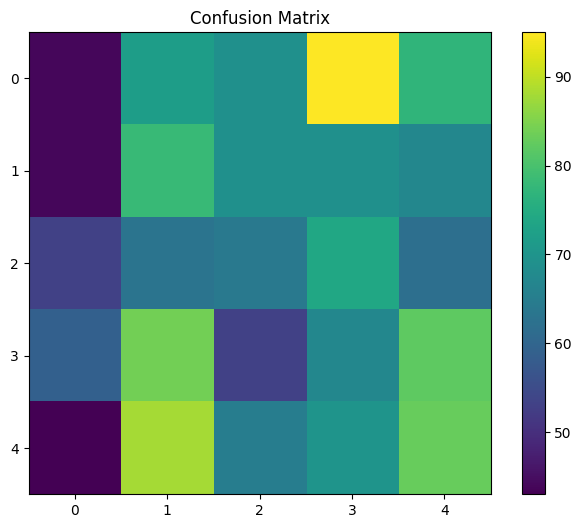

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [16]:
y_priority = df['Ticket Priority']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_tfidf,
        y_priority,
            test_size=0.2,
                random_state=42
                )

In [17]:
from sklearn.linear_model import LogisticRegression

priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train2, y_train2)

pred2 = priority_model.predict(X_test2)

print("Priority Model Trained")

Priority Model Trained


In [19]:
from sklearn.metrics import accuracy_score

print("Priority Accuracy =", accuracy_score(y_test2, pred2))

Priority Accuracy = 0.26977567886658793


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test2, pred2))

              precision    recall  f1-score   support

    Critical       0.25      0.26      0.25       411
        High       0.28      0.28      0.28       409
         Low       0.28      0.28      0.28       415
      Medium       0.28      0.26      0.27       459

    accuracy                           0.27      1694
   macro avg       0.27      0.27      0.27      1694
weighted avg       0.27      0.27      0.27      1694



In [21]:
sample = [
        "Customer cannot login and access account"
]

sample_clean = [clean_text(x) for x in sample]

sample_vec = tfidf.transform(sample_clean)

print("Predicted Category:")
print(category_model.predict(sample_vec)[0])

print("Predicted Priority:")
print(priority_model.predict(sample_vec)[0])

Predicted Category:
Cancellation request
Predicted Priority:
High
